# parallel workflow  example cricket workflow
# state having runs balls 4s and 6s strickrate,   ball percentage, boundary per ball
 

In [1]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict
import os 


In [3]:
class BatsmanState(TypedDict):
    runs: int
    balls: int
    fours: int
    sixes: int

    sr: float
    bpb: float
    boundary_percentge: float
    summary: str

In [4]:
def calculate_sr(state:BatsmanState):
    sr=(state['runs']/state['balls'])*100

    #state['sr']=sr
    return {'sr':sr}

In [5]:
def calculate_bpb(state: BatsmanState):
    bpb=state['balls']/(state['fours']+state['sixes'])
    #state['bpb']=bpb
    return {'bpb':bpb}

In [6]:
def caluclate_boundary_percentage(state: BatsmanState):
    b_p=(((state['fours']*4)+(state['sixes']*6))/state['runs'])*100

    #state['boundary_percentge']=b_p
    return {'boundary_percentge':b_p}

In [7]:
def summary(state: BatsmanState):
    summary=f"""
    Strike Rate - {state['sr']}\n
    Balls per Boundary - {state['bpb']}\n
    boundary_percentge - {state['boundary_percentge']}
     """
    # state['summary']=summary
    return {'summary':summary}

In [8]:
graph=StateGraph(BatsmanState)

#craete node 
graph.add_node('calculate_sr',calculate_sr)
graph.add_node('calculate_bpb',calculate_bpb)
graph.add_node('caluclate_boundary_percentage',caluclate_boundary_percentage)
graph.add_node('summary',summary)




In [9]:
# create edges

graph.add_edge(START,'calculate_sr')
graph.add_edge(START,'calculate_bpb')
graph.add_edge(START,'caluclate_boundary_percentage')

graph.add_edge('calculate_sr','summary')
graph.add_edge('calculate_bpb','summary')
graph.add_edge('caluclate_boundary_percentage','summary')

graph.add_edge('summary',END)




In [10]:
workflow=graph.compile()


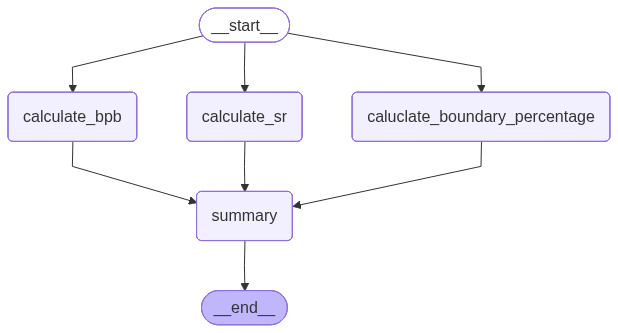

In [12]:
workflow

In [11]:
initial_state={
    'runs':100,
    'balls':50,
    'fours':10,
    'sixes':4
}

final_state=workflow.invoke(initial_state)


In [13]:
final_state['summary']


'\n    Strike Rate - 200.0\n\n    Balls per Boundary - 3.5714285714285716\n\n    boundary_percentge - 64.0\n     '